In [1]:
import pandas as pd

# Load the original dataset
df = pd.read_parquet("../data/raw_data/daily_weather.parquet")

print("Dataset Shape:", df.shape)

Dataset Shape: (27635763, 14)


In [2]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['station_id', 'city_name', 'date', 'season', 'avg_temp_c', 'min_temp_c', 'max_temp_c', 'precipitation_mm', 'snow_depth_mm', 'avg_wind_dir_deg', 'avg_wind_speed_kmh', 'peak_wind_gust_kmh', 'avg_sea_level_pres_hpa', 'sunshine_total_min']


In [3]:
df.dtypes

station_id                      category
city_name                       category
date                      datetime64[us]
season                          category
avg_temp_c                       float64
min_temp_c                       float64
max_temp_c                       float64
precipitation_mm                 float64
snow_depth_mm                    float64
avg_wind_dir_deg                 float64
avg_wind_speed_kmh               float64
peak_wind_gust_kmh               float64
avg_sea_level_pres_hpa           float64
sunshine_total_min               float64
dtype: object

In [4]:
print("Starting Date:", df["date"].min())
print("Ending Date:", df["date"].max())

Starting Date: 1750-02-01 00:00:00
Ending Date: 2023-09-05 00:00:00


In [5]:
print("Unique Cities:", df["city_name"].nunique())

Unique Cities: 1234


# Average Temperature Distribution

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:

temp_sample = df["avg_temp_c"].dropna().sample(
    n=200000,
    random_state=42
)

print("Sample Size:", len(temp_sample))

Sample Size: 200000


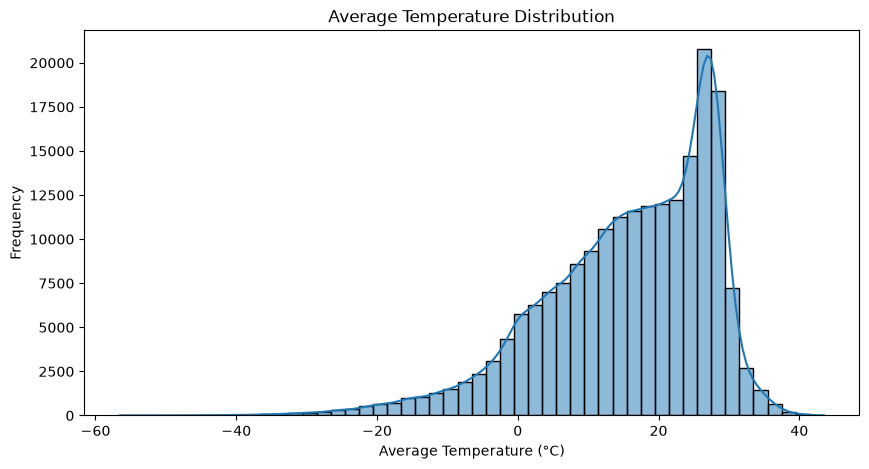

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(
    temp_sample,
    bins=50,
    kde=True
)

plt.title("Average Temperature Distribution")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

# Seasonal Temperature Analysis

In [9]:
# Average temperature by season

season_temperature = df.groupby("season")["avg_temp_c"].mean()

print(season_temperature)

season
Autumn    16.142407
Spring    15.719252
Summer    23.068207
Winter     7.841744
Name: avg_temp_c, dtype: float64


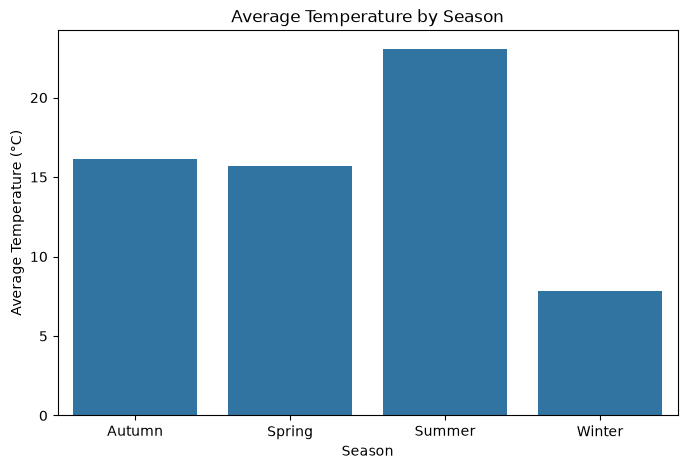

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_temperature.index,
    y=season_temperature.values
)

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")

plt.show()

# Monthly Temperature Analysis

In [11]:
# Extract month from date

df["month"] = df["date"].dt.month

print(df[["date", "month"]].head())

        date  month
0 1957-07-01      7
1 1957-07-02      7
2 1957-07-03      7
3 1957-07-04      7
4 1957-07-05      7


In [12]:
# Average temperature by month

monthly_temperature = df.groupby("month")["avg_temp_c"].mean()

print(monthly_temperature)

month
1      7.771558
2      9.022771
3     12.150916
4     15.910229
5     19.143204
6     21.520057
7     22.802664
8     22.401391
9     19.813427
10    16.330491
11    12.251318
12     8.983111
Name: avg_temp_c, dtype: float64


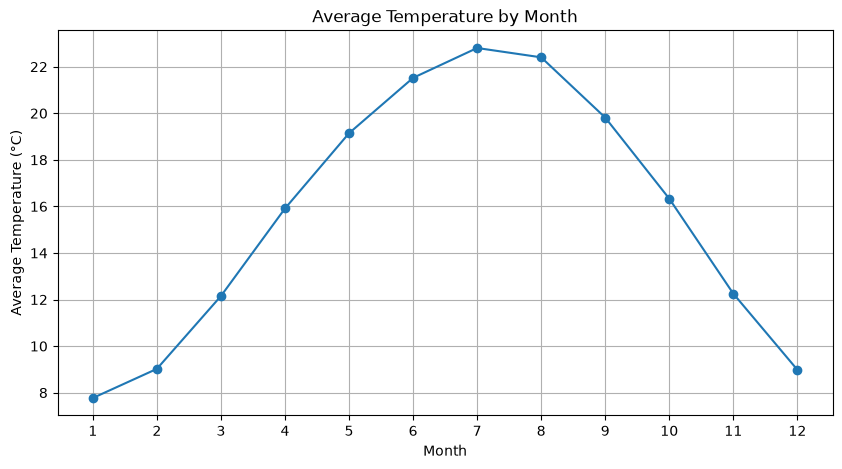

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_temperature.index,
    monthly_temperature.values,
    marker="o"
)

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.xticks(range(1, 13))

plt.grid(True)
plt.show()

# City-wise Temperature Analysis

In [14]:
# Average temperature by city

city_temperature = (
    df.groupby("city_name")["avg_temp_c"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

city_temperature.head(10)

city_name
Faya-Largeau    31.273885
Kaédi           30.680517
Jizan           30.532035
Sana'a          30.532035
Khartoum        30.315657
Am Timan        30.210499
Agadez          30.017098
Yola            29.907237
Bolgatanga      29.882320
Kayes           29.859245
Name: avg_temp_c, dtype: float64

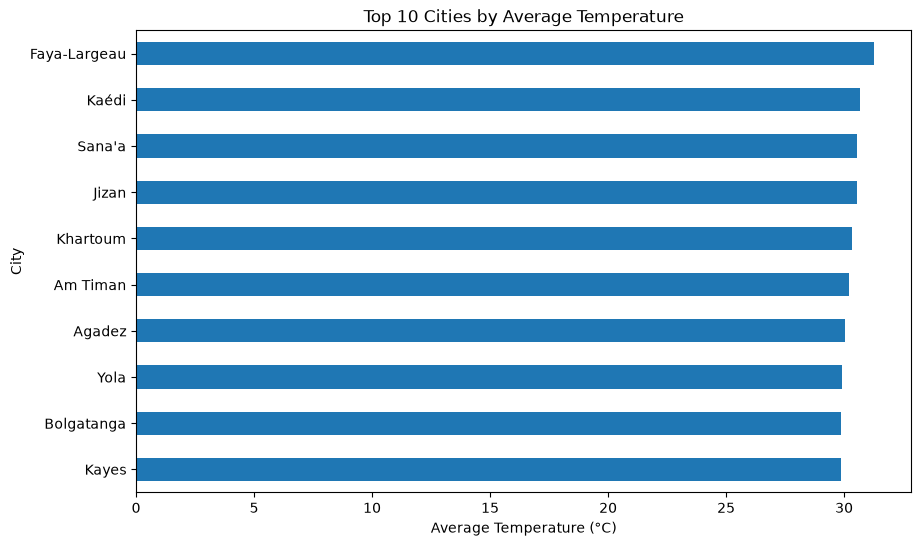

In [15]:
plt.figure(figsize=(10, 6))

city_temperature.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Cities by Average Temperature")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("City")

plt.show()

# Coldest Cities

In [16]:
# Average temperature by city (coldest)

coldest_cities = (
    df.groupby("city_name")["avg_temp_c"]
    .mean()
    .dropna()
    .sort_values(ascending=True)
)

coldest_cities.head(10)

city_name
Yakutsk        -9.351856
Tura           -8.520626
Anadyr         -7.134536
Karakol        -6.555714
Salekhard      -5.989391
Longyearbyen   -4.501992
Yellowknife    -3.715263
Naryan-Mar     -3.283867
Magadan        -3.176641
Ulaangom       -2.456123
Name: avg_temp_c, dtype: float64

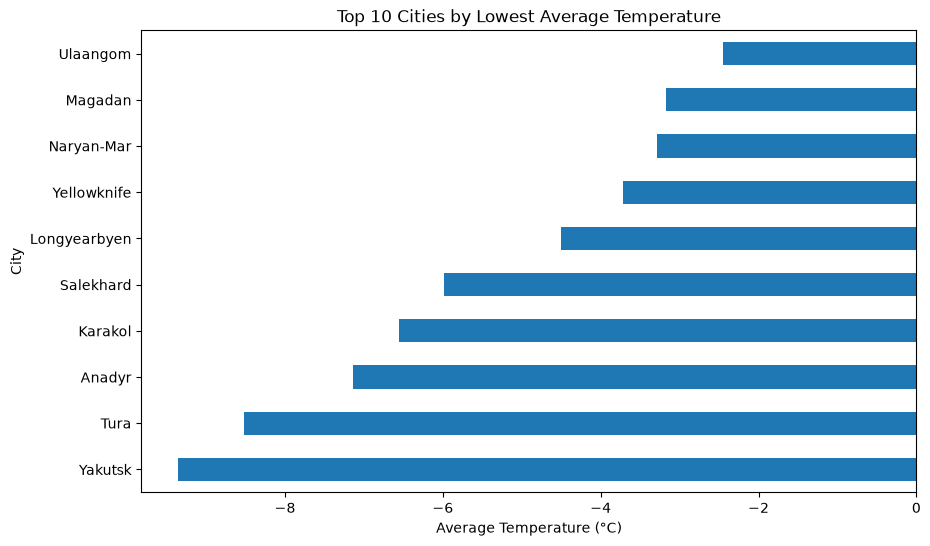

In [17]:
plt.figure(figsize=(10, 6))

coldest_cities.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Cities by Lowest Average Temperature")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("City")

plt.show()

# Precipitation Analysis

In [18]:
# Basic precipitation statistics

precipitation_stats = df["precipitation_mm"].describe()

print(precipitation_stats)

count    2.099326e+07
mean     2.740569e+00
std      9.791887e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      1.000000e+03
Name: precipitation_mm, dtype: float64


In [19]:
# Select valid precipitation values

precipitation_sample = (
    df["precipitation_mm"]
    .dropna()
    .sample(n=200000, random_state=42)
)

print("Sample Size:", len(precipitation_sample))

Sample Size: 200000


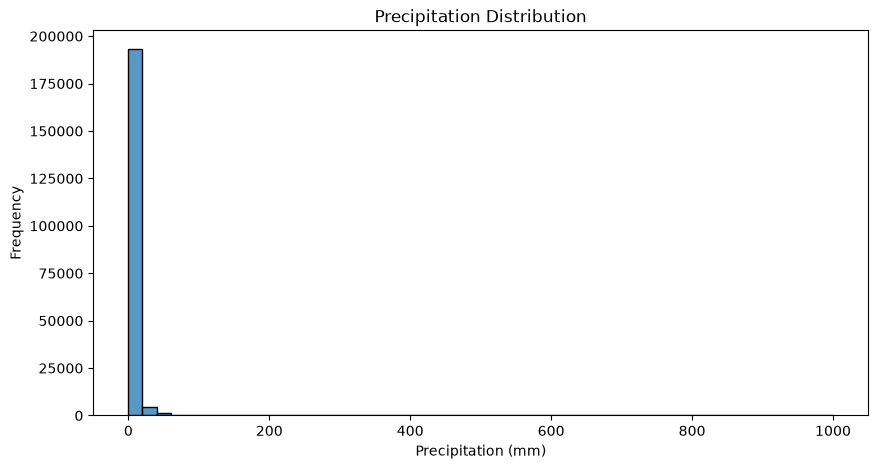

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    precipitation_sample,
    bins=50
)

plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")

plt.show()

# Precipitation by Season

In [21]:
# Average precipitation by season

season_precipitation = (
    df.groupby("season")["precipitation_mm"]
    .mean()
    .sort_values(ascending=False)
)

print(season_precipitation)

season
Summer    3.749143
Autumn    2.983925
Spring    2.332976
Winter    1.843062
Name: precipitation_mm, dtype: float64


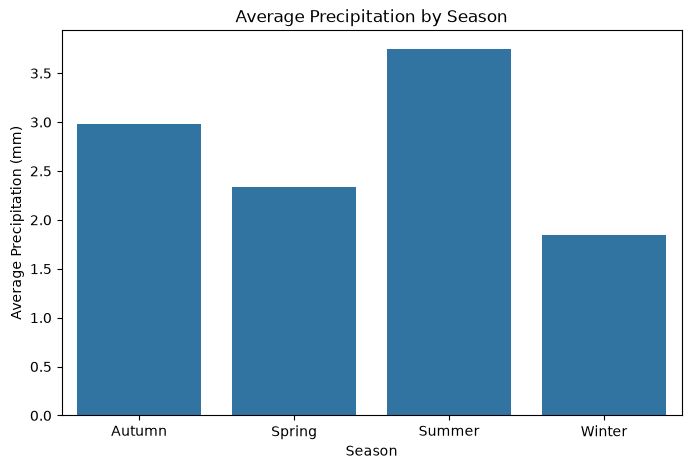

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_precipitation.index,
    y=season_precipitation.values
)

plt.title("Average Precipitation by Season")
plt.xlabel("Season")
plt.ylabel("Average Precipitation (mm)")

plt.show()

# Wind Speed Analysis

In [23]:
# Average wind speed statistics

wind_stats = df["avg_wind_speed_kmh"].describe()

print(wind_stats)

count    5.285468e+06
mean     1.240827e+01
std      7.054249e+00
min      0.000000e+00
25%      7.500000e+00
50%      1.090000e+01
75%      1.570000e+01
max      1.763000e+02
Name: avg_wind_speed_kmh, dtype: float64


In [24]:
# Select valid wind speed values

wind_sample = (
    df["avg_wind_speed_kmh"]
    .dropna()
    .sample(n=200000, random_state=42)
)

print("Sample Size:", len(wind_sample))

Sample Size: 200000


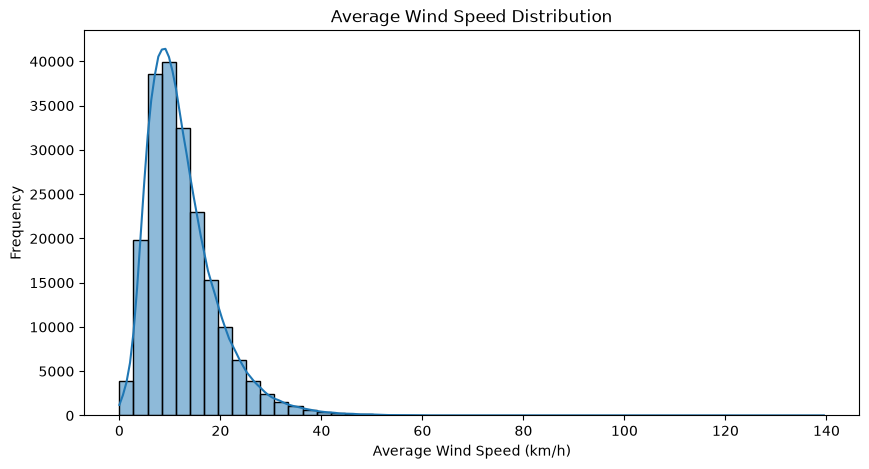

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    wind_sample,
    bins=50,
    kde=True
)

plt.title("Average Wind Speed Distribution")
plt.xlabel("Average Wind Speed (km/h)")
plt.ylabel("Frequency")

plt.show()

# Correlation Analysis

In [26]:
# Select numerical weather columns

numeric_columns = [
    "avg_temp_c",
    "min_temp_c",
    "max_temp_c",
    "precipitation_mm",
    "avg_wind_speed_kmh",
    "avg_sea_level_pres_hpa"
]

correlation_data = df[numeric_columns]

In [27]:
# Calculate correlation matrix

correlation_matrix = correlation_data.corr()

correlation_matrix

,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,avg_wind_speed_kmh,avg_sea_level_pres_hpa
avg_temp_c,1.000000,0.973855,0.981317,0.089205,-0.139695,-0.290633
min_temp_c,0.973855,1.000000,0.925747,0.119419,-0.090668,-0.316841
max_temp_c,0.981317,0.925747,1.000000,0.051974,-0.183971,-0.253817
precipitation_mm,0.089205,0.119419,0.051974,1.000000,0.029550,-0.163721
avg_wind_speed_kmh,-0.139695,-0.090668,-0.183971,0.029550,1.000000,-0.174878
avg_sea_level_pres_hpa,-0.290633,-0.316841,-0.253817,-0.163721,-0.174878,1.000000


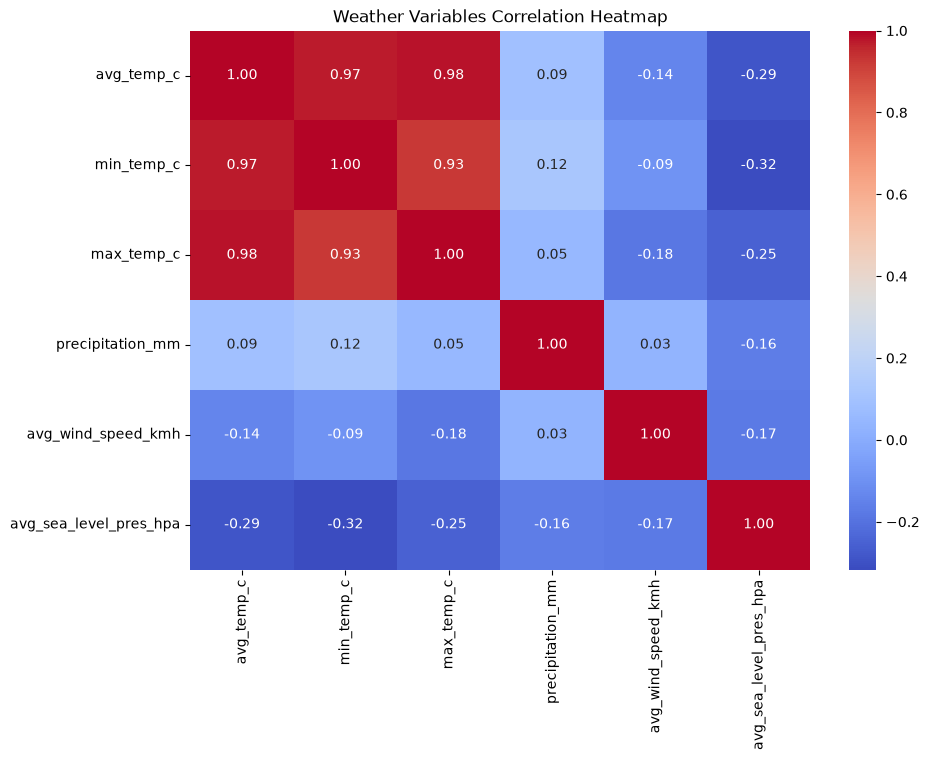

In [28]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Weather Variables Correlation Heatmap")

plt.show()

# EDA Summary

## Dataset Overview
- Total Rows: 27,635,763
- Total Columns: 14
- Unique Cities: 1,234
- Date Range: 1750–2023

## Data Quality
- Duplicate Rows: 21,280
- Missing values are present in several weather variables.
- Date column is in datetime format.

## Temperature Analysis
- Highest seasonal average: Summer (23.07°C)
- Lowest seasonal average: Winter (7.84°C)
- Highest monthly average: July (22.80°C)
- Lowest monthly average: January (7.77°C)

## Precipitation Analysis
- Average precipitation: 2.74 mm
- Median precipitation: 0 mm
- Summer has the highest seasonal average precipitation.

## Wind Speed Analysis
- Average wind speed: 12.41 km/h
- Maximum observed wind speed: 176.30 km/h

## Correlation Analysis
- Average temperature and maximum temperature: 0.98
- Average temperature and minimum temperature: 0.97
- Average temperature and sea-level pressure: -0.29